# Survival Analysis — An Illustrated Tour

> Inspired by **ISLR Ch. 11**.

Survival data has **two complications** ordinary regression doesn't:

1. The outcome is a **time-to-event** ($T$), which can be huge or small.
2. Some subjects are **censored** — we only know $T > t_c$ for them.

Three core tools:

| Tool | Question it answers |
|---|---|
| Kaplan–Meier estimator | What fraction is event-free at time $t$? |
| Log-rank test | Do two groups have the same survival curve? |
| Cox proportional hazards | How does covariate $x$ shift the hazard? |


## The picture — survival curve drops over time; hazard governs the rate

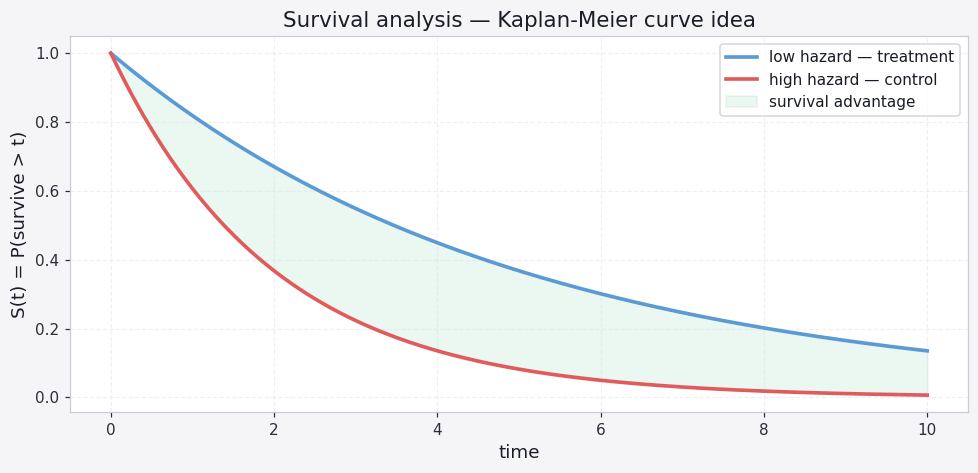

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
t = np.linspace(0, 10, 300)
S1 = np.exp(-0.2*t); S2 = np.exp(-0.5*t)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(t, S1, color=P[0], lw=2.4, label='low hazard — treatment')
ax.plot(t, S2, color=P[1], lw=2.4, label='high hazard — control')
ax.fill_between(t, S1, S2, alpha=0.15, color=P[3], label='survival advantage')
ax.set_xlabel('time'); ax.set_ylabel('S(t) = P(survive > t)')
ax.set_title('Survival analysis — Kaplan-Meier curve idea')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import pandas as pd

rng = np.random.RandomState(0)
n = 200
group = rng.binomial(1, 0.5, n)              # 0 = control, 1 = treatment
age   = rng.normal(60, 10, n)
# treatment halves hazard; older = higher hazard
hazard = 0.05 * np.exp(-0.7*group + 0.03*(age - 60))
T_true = rng.exponential(1.0/hazard)         # event time
C      = rng.exponential(15, n)              # censoring time
T_obs  = np.minimum(T_true, C)
event  = (T_true <= C).astype(int)

df = pd.DataFrame({'T': T_obs, 'E': event, 'group': group, 'age': age})
print(df.head())
print('Event rate:', event.mean())


           T  E  group        age
0  16.692957  0      1  71.266359
1   6.340347  0      1  49.200685
2  18.764230  0      1  48.525313
3  12.468114  1      1  55.621800
4   7.641428  0      0  55.019675
Event rate: 0.325


---
## 1. Kaplan–Meier survival curves


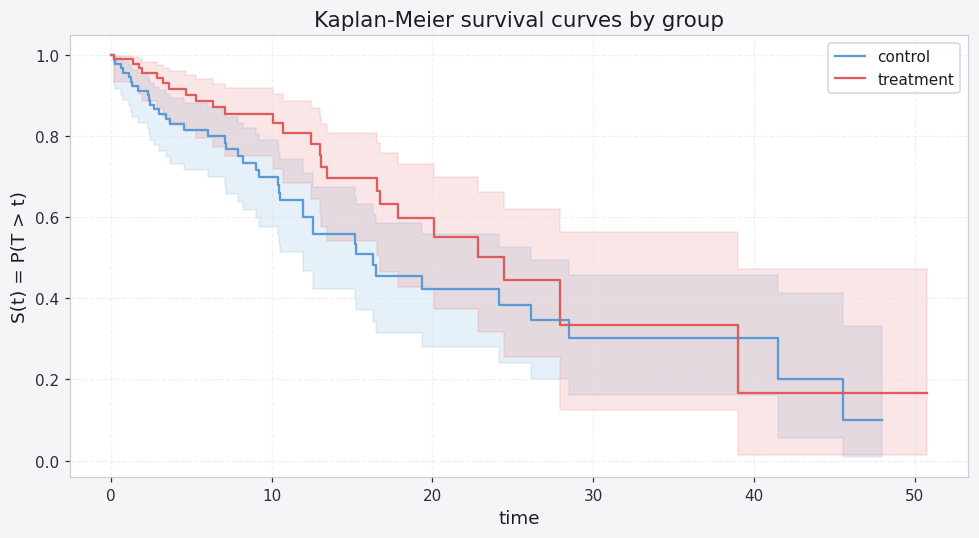

Log-rank p-value = 0.08588  (test statistic = 2.95)


In [3]:
km = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(9, 5))
for g, name, col in [(0, 'control', PALETTE[0]), (1, 'treatment', PALETTE[1])]:
    mask = df['group'] == g
    km.fit(df.loc[mask, 'T'], df.loc[mask, 'E'], label=name)
    km.plot_survival_function(ax=ax, color=col, ci_alpha=0.15)
ax.set_title('Kaplan-Meier survival curves by group')
ax.set_xlabel('time'); ax.set_ylabel('S(t) = P(T > t)')
ax.grid(True)
plt.tight_layout(); plt.show()

# Log-rank test
res = logrank_test(df.loc[df.group==0, 'T'], df.loc[df.group==1, 'T'],
                    event_observed_A=df.loc[df.group==0, 'E'],
                    event_observed_B=df.loc[df.group==1, 'E'])
print(f'Log-rank p-value = {res.p_value:.4g}  (test statistic = {res.test_statistic:.2f})')


---
## 2. Cox proportional hazards

$$h(t \mid x) = h_0(t)\,\exp(\beta_1 x_1 + \dots + \beta_p x_p)$$

The exponentiated coefficient $e^{\beta_j}$ is the **hazard ratio** for a unit change in $x_j$.


<lifelines.CoxPHFitter: fitted with 200 total observations, 135 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 65
   partial log-likelihood = -268.08
         time fit was run = 2026-05-31 11:06:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
group     -0.39      0.68      0.26           -0.89            0.12                0.41                1.13
age        0.04      1.05      0.01            0.02            0.07                1.02                1.07

           cmp to     z      p  -log2(p)
covariate                               
group        0.00 -1.49   0.14      2.89
age          0.00  3.16 <0.005      9.32
---
Concordance = 0.62
Partial AIC = 540.15
log-likelihood ratio test = 13.18 on 2 df
-log2(p) of ll-ratio test = 9.51

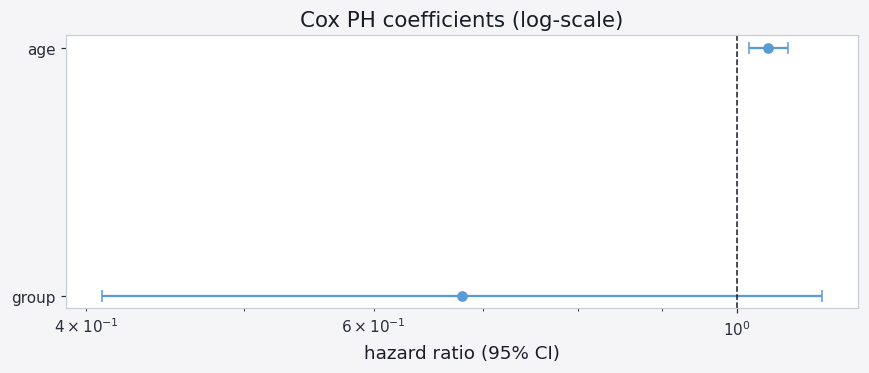

In [4]:
cox = CoxPHFitter()
cox.fit(df, duration_col='T', event_col='E')
cox.print_summary()

fig, ax = plt.subplots(figsize=(8, 3.5))
hr = np.exp(cox.params_)
ci_lo, ci_hi = np.exp(cox.confidence_intervals_['95% lower-bound']), np.exp(cox.confidence_intervals_['95% upper-bound'])
ax.errorbar(hr, np.arange(len(hr)), xerr=[hr - ci_lo, ci_hi - hr], fmt='o', color=PALETTE[0], capsize=4)
ax.axvline(1, color='#1a1d27', ls='--', lw=1)
ax.set_yticks(np.arange(len(hr))); ax.set_yticklabels(hr.index)
ax.set_xscale('log'); ax.set_xlabel('hazard ratio (95% CI)')
ax.set_title('Cox PH coefficients (log-scale)')
ax.grid(True, axis='x')
plt.tight_layout(); plt.show()


---
## What we just saw

- **KM curves** show step-down failure functions; treatment cohort stays event-free longer.
- The **log-rank test** rejects equality of curves — the difference is real.
- **Cox PH** quantifies the effect: hazard ratio for `group=1` should be roughly $e^{-0.7} \approx 0.5$ (treatment halves the hazard); `age` has HR $> 1$ (older = riskier).

> Lesson: never throw away censored rows. They contain real information and standard regression can't use it correctly. Always reach for survival tools when time-to-event data appears.
